# Unusual Seasons — PEP725 Fruit Trees

Identifies observations that correspond to **climatologically unusual seasons**: years in which bloom timing departs substantially from what is expected at that location and species.

A season is considered unusual when its bloom DOY z-score (relative to the long-term site climatology) exceeds a configurable threshold.

Key questions:
1. **Which individual observations are outliers?**
2. **Which years are systemically unusual** — early or late across many species and sites?
3. **Are unusual years spatially clustered**, or do they reflect a Europe-wide signal?
4. **Are the anomalies species-consistent?** — if all species bloom early in year X, it is likely a genuine climate anomaly rather than a data error.
5. **Temperature check** — do bloom anomalies align with winter/spring temperature anomalies?

## Config

In [10]:
TARGET_OBS        = 'BBCH_60'
YEAR_MIN          = 1986
YEAR_MAX          = 2024

# Minimum years of data at a (species, location) to compute a reliable climatology
MIN_CLIM_YEARS    = 5

# |z-score| threshold to flag an observation as unusual
Z_THRESH          = 2.5

# Also flag using IQR method (observation outside Q1 - k*IQR or Q3 + k*IQR)
IQR_K             = 2.5

# Set to False to include observations removed as outliers by default preprocessing
REMOVE_OUTLIERS   = False

# Temperature download (requires OpenMeteo; slow on first run)
DOWNLOAD_TEMPERATURE = False


## 1. Load data

In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

from pysephone.constants import KEY_OBS_TYPE, KEY_OBSERVATIONS, KEY_SPECIES_ID, KEY_FEATURES
from pysephone.data.pep725.source import PEP725Source
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.preprocessing.pep725 import get_pep725_dataframes
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.models.util.func_phenology import func_chilling_days

_SRC = PEP725Source.KEY  # 'pep725'

# Fruit tree species included in PEP725_fruit_trees (all subgroups)
FRUIT_TREE_SPECIES = [
    (_SRC, 220),  # Malus domestica     (apple)
    (_SRC, 227),  # Pyrus communis      (pear)
    (_SRC, 202),  # Prunus persica      (peach)
    (_SRC, 782),  # Prunus amygdalis    (almond)
    (_SRC, 107),  # Corylus avellana    (hazel)
    (_SRC, 222),  # Prunus avium        (cherry)
    (_SRC, 205),  # Prunus armeniaca    (apricot)
    (_SRC, 225),  # Prunus domestica    (plum)
    (_SRC, 123),  # Prunus spinosa      (blackthorn)
]

cal       = Calendar(default_start='10-01', default_length=365)
features  = OpenMeteoFeatures(calendar=cal) if DOWNLOAD_TEMPERATURE else None
providers = [features] if features else []

raw_data = PEP725Source().get_data({})
dfs = get_pep725_dataframes(
    raw_data,
    filter_on_species=FRUIT_TREE_SPECIES,
    filter_on_observation_types=[TARGET_OBS],
    filter_on_years=list(range(YEAR_MIN, YEAR_MAX + 1)),
    remove_outliers=REMOVE_OUTLIERS,
    datetime_observations=True,
)
obs = Observations(dfs['data'], dfs['locations'], species_names=dfs.get('species_names'))
ds  = Dataset(obs, calendar=cal, feature_providers=providers)

id_to_name = {sid: name for (src, sid), name in obs.species_names.items()}

df_raw   = obs._df_y.copy()
df_bloom = df_raw.xs(TARGET_OBS, level=KEY_OBS_TYPE).copy()
df_bloom['doy'] = df_bloom[KEY_OBSERVATIONS].dt.dayofyear
df_bloom = df_bloom.reset_index()

locs = obs._df_y_loc.reset_index()
df   = df_bloom.merge(locs, on=['src', 'loc_id'], how='left')
df['species_name'] = df[KEY_SPECIES_ID].map(id_to_name)

print(f'{len(df)} observations | '
      f'{df["loc_id"].nunique()} locations | '
      f'{df["year"].nunique()} years | '
      f'{df[KEY_SPECIES_ID].nunique()} species')


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 43813.95it/s]


235535 observations | 9237 locations | 31 years | 9 species


## 2. Site-level climatology and anomaly scores

For each (species, location) pair with at least `MIN_CLIM_YEARS` years of data, compute the long-term mean and standard deviation of bloom DOY.
Each observation then receives:
- **`anom_days`**: observed DOY − site mean (signed, in days)
- **`anom_z`**: anom_days / site std (z-score)

Observations at pairs with fewer than `MIN_CLIM_YEARS` years are retained but have `NaN` anomaly scores.

In [12]:
# ── Site climatology ────────────────────────────────────────────────────
clim = (
    df.groupby(['species_name', 'loc_id'])['doy']
      .agg(clim_mean='mean', clim_std='std', n_clim='count')
      .reset_index()
)
# Only use sites with enough years for a reliable std
clim.loc[clim['n_clim'] < MIN_CLIM_YEARS, ['clim_mean', 'clim_std']] = np.nan

df = df.merge(clim, on=['species_name', 'loc_id'], how='left')
df['anom_days'] = df['doy'] - df['clim_mean']
df['anom_z']    = df['anom_days'] / df['clim_std']

# ── Flag unusual observations ────────────────────────────────────────────
df['unusual_z']   = df['anom_z'].abs() > Z_THRESH
df['unusual_dir'] = np.where(
    df['anom_z'] >  Z_THRESH, 'late',
    np.where(df['anom_z'] < -Z_THRESH, 'early', 'normal')
)

# IQR method (per species, pooled across all sites)
def _iqr_flag(series, k=IQR_K):
    q25, q75 = series.quantile([0.25, 0.75])
    iqr = q75 - q25
    return (series < q25 - k * iqr) | (series > q75 + k * iqr)

df['unusual_iqr'] = (
    df.groupby('species_name')['anom_days']
      .transform(_iqr_flag)
)

# Combined flag: flagged by either method
df['unusual'] = df['unusual_z'].fillna(False) | df['unusual_iqr'].fillna(False)

n_scored   = df['anom_z'].notna().sum()
n_unusual  = df['unusual_z'].sum()
n_iqr      = df['unusual_iqr'].sum()
n_combined = df['unusual'].sum()
print(f'Observations with anomaly score: {n_scored} / {len(df)}')
print(f'Unusual by z-score (|z| > {Z_THRESH}):  {n_unusual}  ({n_unusual/n_scored:.1%})')
print(f'Unusual by IQR (k={IQR_K}):             {n_iqr}  ({n_iqr/n_scored:.1%})')
print(f'Unusual by either method:               {n_combined}  ({n_combined/n_scored:.1%})')

# Ordered species list
species_order = (
    df.groupby('species_name')['doy'].median().sort_values().index.tolist()
)
palette = dict(zip(species_order, sns.color_palette('tab10', len(species_order))))


Observations with anomaly score: 209616 / 235535
Unusual by z-score (|z| > 2.5):  1453  (0.7%)
Unusual by IQR (k=2.5):             599  (0.3%)
Unusual by either method:               1692  (0.8%)


## 3. Anomaly distribution per species

Distribution of site-adjusted DOY anomalies. The z-score threshold is shown as dashed lines. A heavy tail indicates that unusual seasons are not rare.

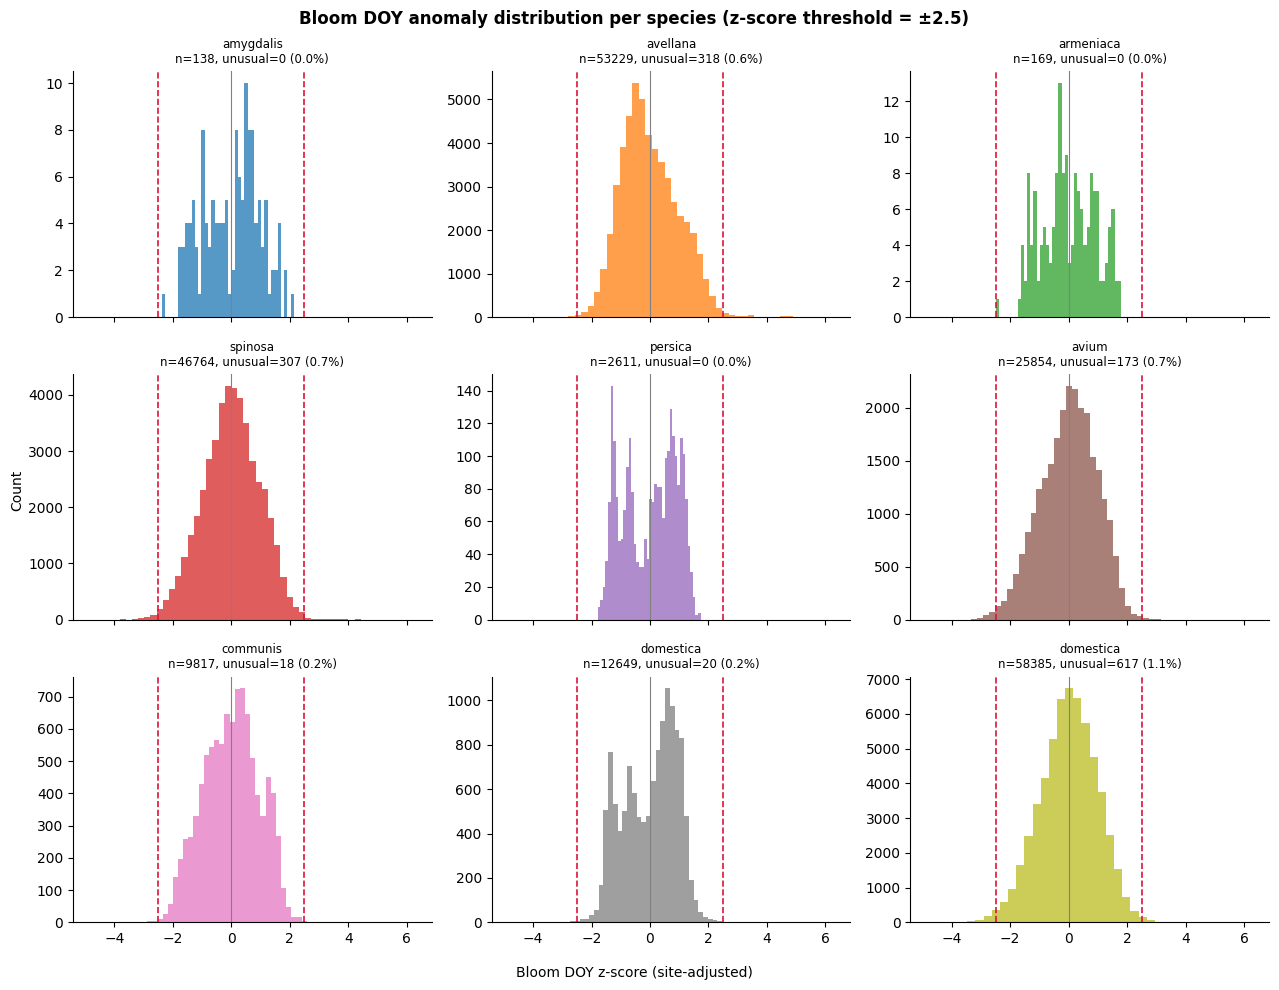

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True)
fig.suptitle(f'Bloom DOY anomaly distribution per species '
             f'(z-score threshold = ±{Z_THRESH})',
             fontsize=12, fontweight='bold')

for ax, sp in zip(axes.flat, species_order):
    sub = df[df['species_name'] == sp]['anom_z'].dropna()
    if sub.empty:
        ax.set_visible(False)
        continue
    n_out = (sub.abs() > Z_THRESH).sum()
    ax.hist(sub, bins=40, color=palette[sp], alpha=0.75, edgecolor='none')
    ax.axvline(-Z_THRESH, color='crimson', lw=1.2, ls='--')
    ax.axvline( Z_THRESH, color='crimson', lw=1.2, ls='--')
    ax.axvline(0, color='grey', lw=0.8)
    ax.set_title(f'{sp.split()[-1]}\n'
                 f'n={len(sub)}, unusual={n_out} ({n_out/len(sub):.1%})',
                 fontsize=8.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused subplots
for ax in axes.flat[len(species_order):]:
    ax.set_visible(False)

fig.supxlabel('Bloom DOY z-score (site-adjusted)', fontsize=10)
fig.supylabel('Count', fontsize=10)
plt.tight_layout()
plt.show()


## 4. Which years are systemically unusual?

A year is systemically unusual if many species and sites simultaneously show anomalous bloom timing. This is a strong signal of a Europe-wide climate event (e.g. an exceptionally warm spring).

We aggregate the mean z-score per (year, species) and look for years where multiple species have the same sign anomaly.

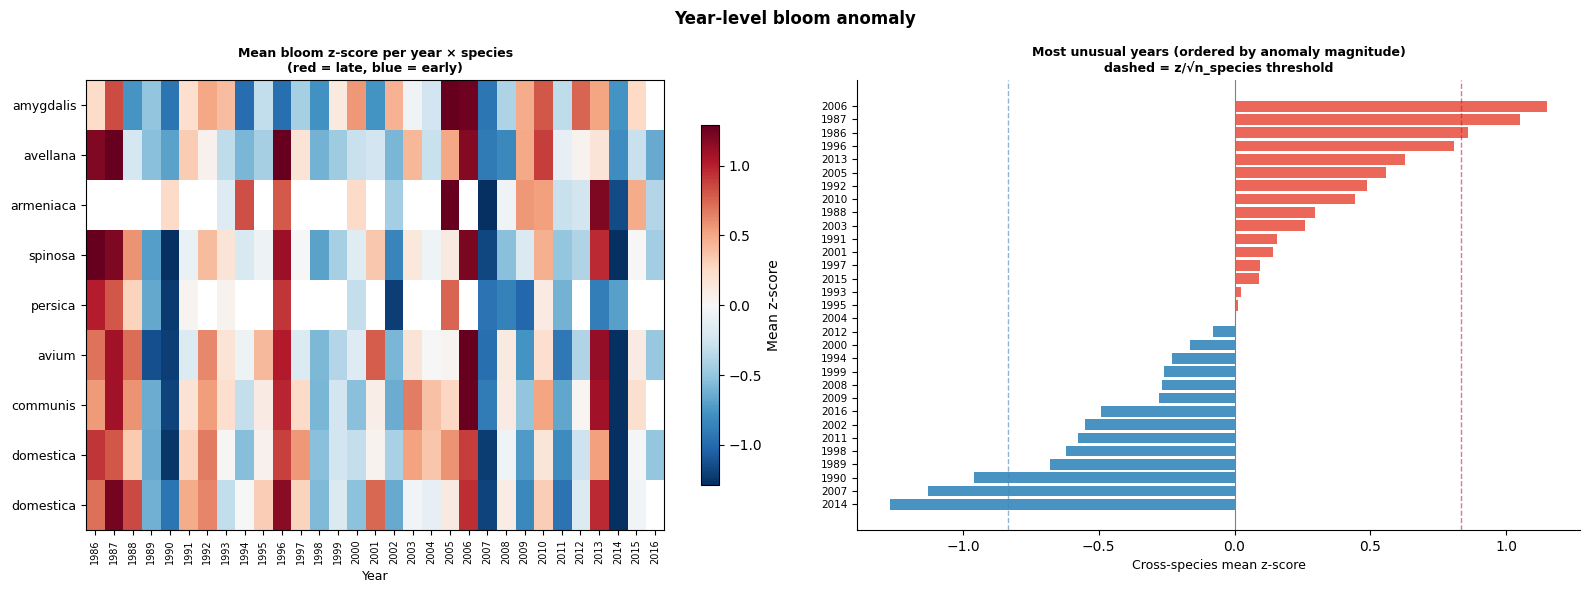

Most extreme years (cross-species mean z-score):
  2014  EARLY  mean z = -1.27
  2007  EARLY  mean z = -1.13
  1990  EARLY  mean z = -0.96
  1989  EARLY  mean z = -0.68
  1998  EARLY  mean z = -0.62
  2013  LATE   mean z = +0.63
  1996  LATE   mean z = +0.81
  1986  LATE   mean z = +0.86
  1987  LATE   mean z = +1.05
  2006  LATE   mean z = +1.15


In [14]:
# ── Year × species mean z-score ─────────────────────────────────────────
yr_sp_z = (
    df.groupby(['year', 'species_name'])['anom_z']
      .agg(mean_z='mean', n='count')
      .reset_index()
)

# Pivot to year × species matrix
mat_z = yr_sp_z.pivot(index='year', columns='species_name', values='mean_z')
mat_z = mat_z.reindex(columns=species_order)

# Cross-species mean z per year
year_mean_z = mat_z.mean(axis=1).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-level bloom anomaly', fontsize=12, fontweight='bold')

# — Heatmap ────────────────────────────────────────────────────────────
ax = axes[0]
vmax = np.nanpercentile(mat_z.abs().values, 95)
im = ax.imshow(mat_z.values.T, cmap='RdBu_r', aspect='auto',
               vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean z-score', shrink=0.8)
ax.set_xticks(range(len(mat_z.index)))
ax.set_xticklabels(mat_z.index, rotation=90, fontsize=7)
ax.set_yticks(range(len(species_order)))
ax.set_yticklabels([s.split()[-1] for s in species_order], fontsize=9)
ax.set_xlabel('Year', fontsize=9)
ax.set_title('Mean bloom z-score per year × species\n'
             '(red = late, blue = early)', fontsize=9, fontweight='bold')

# — Cross-species mean z bar chart ─────────────────────────────────────
ax = axes[1]
colors = ['#e74c3c' if v > 0 else '#2980b9' for v in year_mean_z.values]
ax.barh(range(len(year_mean_z)), year_mean_z.values, color=colors, alpha=0.85)
ax.axvline(0, color='grey', lw=0.8)
ax.axvline( Z_THRESH / len(species_order)**0.5, color='crimson',
            lw=1, ls='--', alpha=0.6)
ax.axvline(-Z_THRESH / len(species_order)**0.5, color='steelblue',
            lw=1, ls='--', alpha=0.6)
ax.set_yticks(range(len(year_mean_z)))
ax.set_yticklabels(year_mean_z.index.astype(str), fontsize=7.5)
ax.set_xlabel('Cross-species mean z-score', fontsize=9)
ax.set_title('Most unusual years (ordered by anomaly magnitude)\n'
             'dashed = z/√n_species threshold', fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Most extreme years (cross-species mean z-score):')
extreme = pd.concat([year_mean_z.head(5), year_mean_z.tail(5)])
for yr, z in extreme.items():
    direction = 'EARLY' if z < 0 else 'LATE '
    print(f'  {int(yr)}  {direction}  mean z = {z:+.2f}')


## 5. Cross-species consistency

If an unusual year affects all species in the same direction, it is almost certainly a real climate signal. If only one species is flagged, it may be a data quality issue or a species-specific biological response.

The plot shows, for each unusually early/late year, how many species share the dominant anomaly direction.

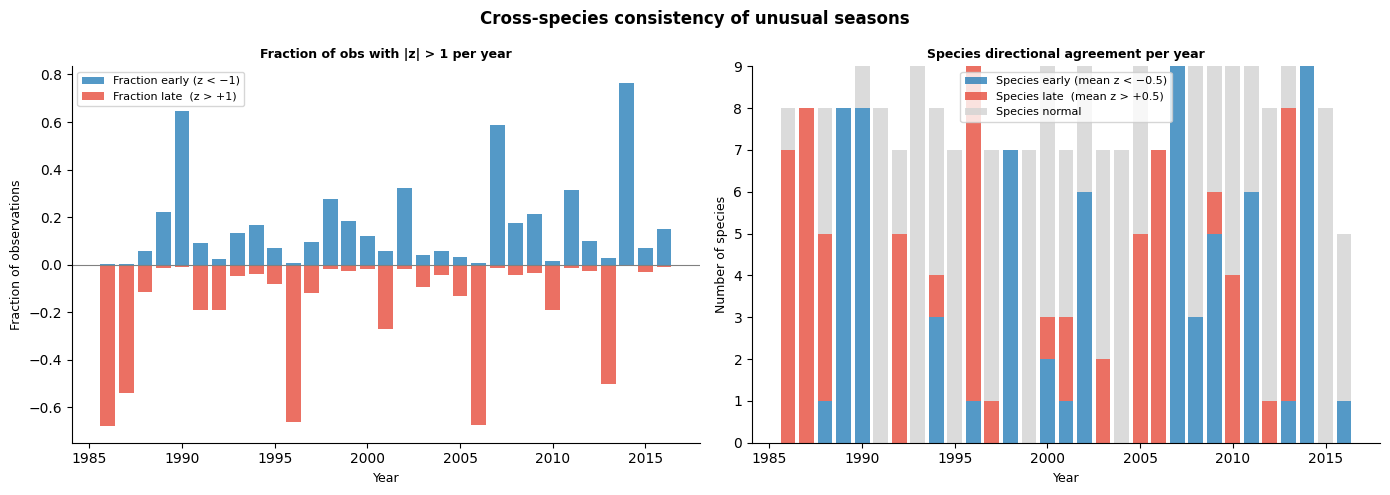

In [15]:
# For each year: fraction of species with z < -1 (early) vs > +1 (late)
yr_dir = (
    df[df['anom_z'].notna()]
      .groupby('year')
      .apply(lambda g: pd.Series({
          'frac_early': (g['anom_z'] < -1).mean(),
          'frac_late':  (g['anom_z'] >  1).mean(),
          'n_sp': g['species_name'].nunique(),
          'mean_z': g['anom_z'].mean(),
      }), include_groups=False)
      .reset_index()
)
yr_dir['dominant'] = np.where(
    yr_dir['frac_early'] > yr_dir['frac_late'], 'early', 'late')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-species consistency of unusual seasons',
             fontsize=12, fontweight='bold')

# — Fraction early vs late per year ────────────────────────────────────
ax = axes[0]
ax.bar(yr_dir['year'], yr_dir['frac_early'],
       label='Fraction early (z < −1)', color='#2980b9', alpha=0.8)
ax.bar(yr_dir['year'], -yr_dir['frac_late'],
       label='Fraction late  (z > +1)', color='#e74c3c', alpha=0.8)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Fraction of observations', fontsize=9)
ax.set_title('Fraction of obs with |z| > 1 per year', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# — Species agreement per year ─────────────────────────────────────────
# For each year, how many species have mean_z in same direction as the overall mean
yr_sp_dir = (
    mat_z.apply(lambda row: pd.Series({
        'n_early': (row < -0.5).sum(),
        'n_late':  (row >  0.5).sum(),
        'n_normal': (row.abs() <= 0.5).sum(),
    }), axis=1)
    .reset_index()
)

ax = axes[1]
ax.bar(yr_sp_dir['year'], yr_sp_dir['n_early'],
       label='Species early (mean z < −0.5)', color='#2980b9', alpha=0.8)
ax.bar(yr_sp_dir['year'], yr_sp_dir['n_late'],
       bottom=yr_sp_dir['n_early'],
       label='Species late  (mean z > +0.5)', color='#e74c3c', alpha=0.8)
ax.bar(yr_sp_dir['year'], yr_sp_dir['n_normal'],
       bottom=yr_sp_dir['n_early'] + yr_sp_dir['n_late'],
       label='Species normal', color='lightgrey', alpha=0.8)
ax.set_xlabel('Year', fontsize=9)
ax.set_ylabel('Number of species', fontsize=9)
ax.set_title('Species directional agreement per year',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 6. Spatial distribution of unusual observations

Map of all unusual observations (|z| > threshold), coloured by direction (early = blue, late = red). Spatial clustering suggests a regional climate event; scattered flags suggest data quality issues.

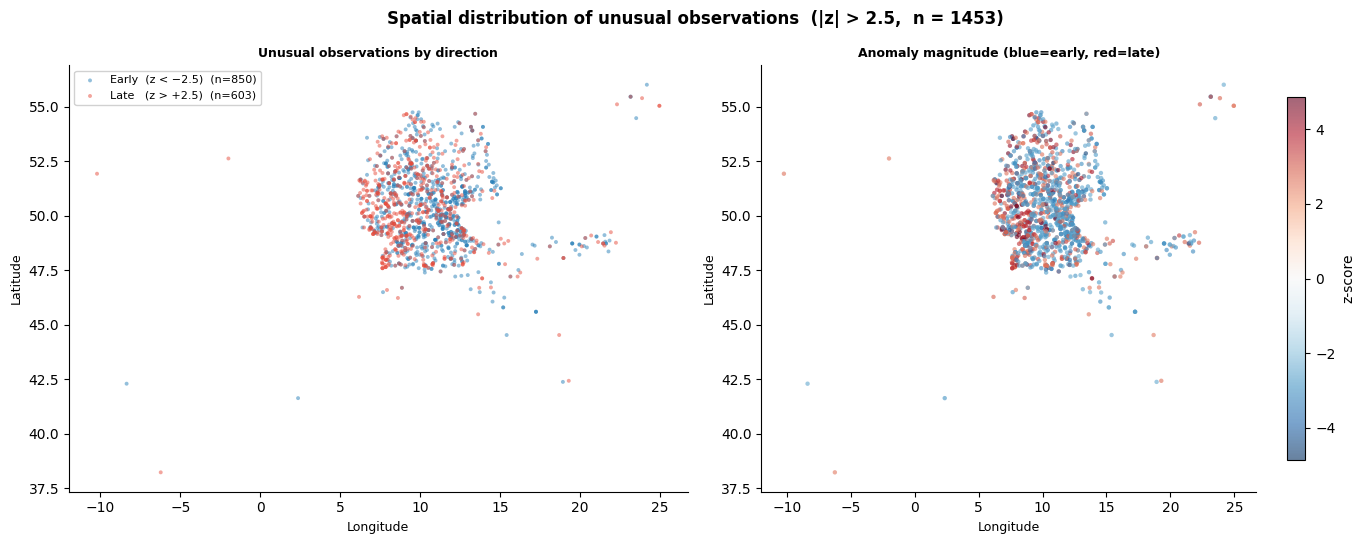

Unusual obs by species:
                   n_unusual  n_early  n_late   mean_anom
species_name                                             
Prunus amygdalis         NaN      NaN     NaN         NaN
Corylus avellana       318.0     37.0   281.0  176.713696
Prunus armeniaca         NaN      NaN     NaN         NaN
Prunus spinosa         307.0    218.0    89.0   -8.610997
Prunus persica           NaN      NaN     NaN         NaN
Prunus avium           173.0    140.0    33.0  -10.065169
Pyrus communis          18.0     13.0     5.0  -20.162351
Prunus domestica        20.0     12.0     8.0    5.791261
Malus x domestica      617.0    430.0   187.0   -7.978622


In [16]:
unusual_df = df[df['unusual_z'] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(f'Spatial distribution of unusual observations  '
             f'(|z| > {Z_THRESH},  n = {len(unusual_df)})',
             fontsize=12, fontweight='bold')

# — early vs late map ──────────────────────────────────────────────────
ax = axes[0]
for direction, color, label in [
        ('early', '#2980b9', 'Early  (z < −{})'.format(Z_THRESH)),
        ('late',  '#e74c3c', 'Late   (z > +{})'.format(Z_THRESH))]:
    sub = unusual_df[unusual_df['unusual_dir'] == direction]
    ax.scatter(sub['lon'], sub['lat'], c=color, s=8, alpha=0.5,
               label=f'{label}  (n={len(sub)})', edgecolors='none')
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('Unusual observations by direction', fontsize=9, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# — anomaly magnitude scatter ──────────────────────────────────────────
ax = axes[1]
vmax = unusual_df['anom_z'].abs().quantile(0.99)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
sc = ax.scatter(unusual_df['lon'], unusual_df['lat'],
                c=unusual_df['anom_z'], cmap='RdBu_r', norm=norm,
                s=10, alpha=0.6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='z-score', shrink=0.85)
ax.set_xlabel('Longitude', fontsize=9)
ax.set_ylabel('Latitude', fontsize=9)
ax.set_title('Anomaly magnitude (blue=early, red=late)',
             fontsize=9, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('Unusual obs by species:')
print(unusual_df.groupby('species_name').agg(
    n_unusual=('unusual_z', 'count'),
    n_early=('unusual_dir', lambda x: (x=='early').sum()),
    n_late=('unusual_dir', lambda x: (x=='late').sum()),
    mean_anom=('anom_days', 'mean'),
).reindex(species_order).to_string())


## 7. Deep-dive: most unusual years

For the top-3 most unusual years (by absolute cross-species mean z-score), show the spatial distribution and per-species anomaly.

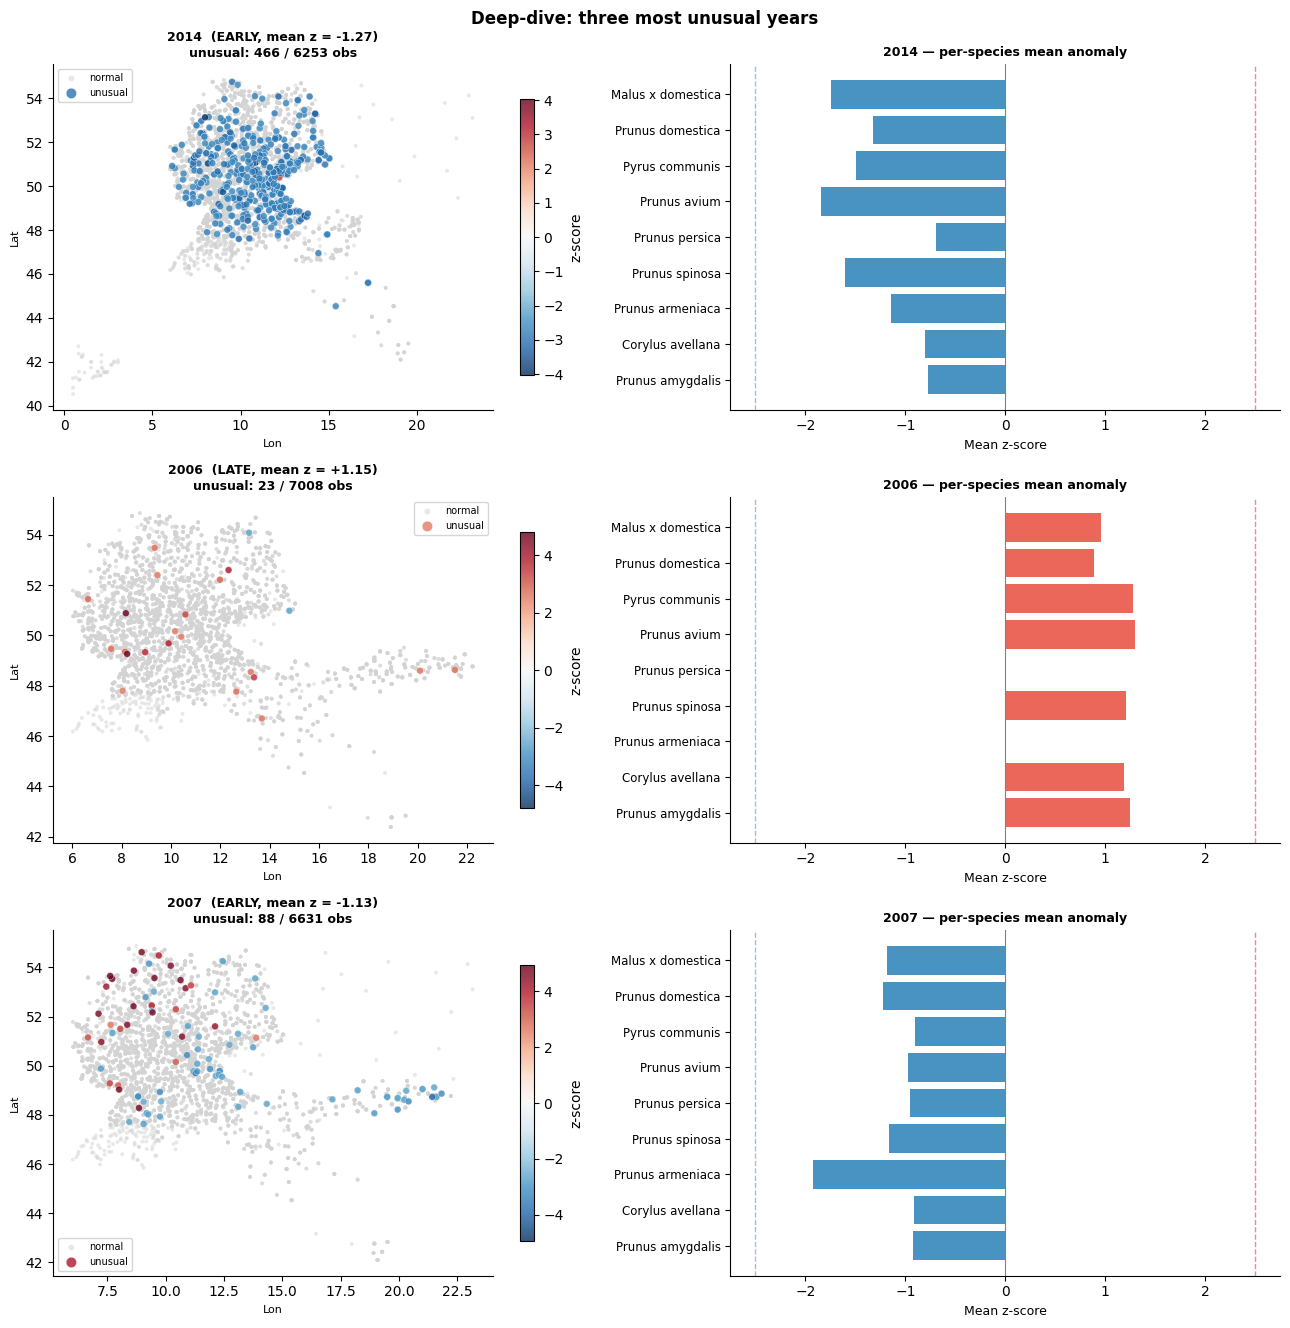

In [17]:
top_years = year_mean_z.abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(len(top_years), 2,
                          figsize=(13, 4.5 * len(top_years)))
if len(top_years) == 1:
    axes = [axes]
fig.suptitle('Deep-dive: three most unusual years', fontsize=12, fontweight='bold')

for row_axes, yr in zip(axes, top_years):
    yr_df = df[df['year'] == yr]
    yr_z  = year_mean_z[yr]
    direction = 'EARLY' if yr_z < 0 else 'LATE'

    # — map ──────────────────────────────────────────────────────────────
    ax = row_axes[0]
    yr_u = yr_df[yr_df['unusual_z'] == True]
    yr_n = yr_df[yr_df['unusual_z'] == False]
    ax.scatter(yr_n['lon'], yr_n['lat'], c='lightgrey', s=8, alpha=0.5,
               edgecolors='none', label='normal')
    if len(yr_u) > 0:
        vmax_yr = yr_u['anom_z'].abs().max()
        norm_yr = mcolors.TwoSlopeNorm(vmin=-vmax_yr, vcenter=0, vmax=vmax_yr)
        sc = ax.scatter(yr_u['lon'], yr_u['lat'],
                        c=yr_u['anom_z'], cmap='RdBu_r', norm=norm_yr,
                        s=25, alpha=0.8, edgecolors='white', linewidths=0.3,
                        label='unusual')
        plt.colorbar(sc, ax=ax, label='z-score', shrink=0.8)
    ax.set_title(f'{yr}  ({direction}, mean z = {yr_z:+.2f})\n'
                 f'unusual: {len(yr_u)} / {len(yr_df)} obs',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Lon', fontsize=8); ax.set_ylabel('Lat', fontsize=8)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # — per-species anomaly ───────────────────────────────────────────────
    ax = row_axes[1]
    sp_z = mat_z.loc[yr].reindex(species_order)
    colors = ['#e74c3c' if v > 0 else '#2980b9'
              if not np.isnan(v) else 'lightgrey'
              for v in sp_z]
    ax.barh(range(len(species_order)), sp_z.fillna(0),
            color=colors, alpha=0.85)
    ax.axvline(0, color='grey', lw=0.8)
    ax.axvline( Z_THRESH, color='crimson', lw=1, ls='--', alpha=0.5)
    ax.axvline(-Z_THRESH, color='steelblue', lw=1, ls='--', alpha=0.5)
    ax.set_yticks(range(len(species_order)))
    ax.set_yticklabels(species_order, fontsize=8.5)
    ax.set_xlabel('Mean z-score', fontsize=9)
    ax.set_title(f'{yr} — per-species mean anomaly', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Temperature check (optional)

Set `DOWNLOAD_TEMPERATURE = True` in the config to download OpenMeteo data. This section then plots bloom anomaly vs winter/spring temperature anomaly, and highlights observations where bloom is unusual but temperature is not — potential data quality flags.

In [18]:
if not DOWNLOAD_TEMPERATURE:
    print('Set DOWNLOAD_TEMPERATURE = True and re-run to enable this section.')
else:
    ds.download_features(verbose=True)

    temp_rows = {}
    for item in ds.iter_items():
        if TARGET_OBS not in item.get('observations_index', {}):
            continue
        key = (item['src'], item['loc_id'], item['year'])
        if key in temp_rows:
            continue
        ts = item[KEY_FEATURES]['temperature_2m_mean'].astype(float)
        temp_rows[key] = {
            'src': item['src'], 'loc_id': item['loc_id'], 'year': item['year'],
            'mean_winter_T': float(ts[:120].mean()),
            'mean_spring_T': float(ts[120:212].mean()),
            'chill_days':    float(func_chilling_days(ts).sum()),
        }

    df_temp = pd.DataFrame(list(temp_rows.values()))

    # Compute temperature anomaly per site
    t_clim = df_temp.groupby('loc_id')[['mean_winter_T','mean_spring_T']].transform(
        lambda x: (x - x.mean()) / x.std()
    ).rename(columns={'mean_winter_T': 'winter_T_z', 'mean_spring_T': 'spring_T_z'})
    df_temp = pd.concat([df_temp, t_clim], axis=1)

    df = df.merge(df_temp, on=['src', 'loc_id', 'year'], how='left')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Bloom anomaly vs temperature anomaly', fontsize=12, fontweight='bold')

    for ax, (col, label) in zip(axes[:2], [
            ('winter_T_z', 'Winter T z-score (Oct–Jan)'),
            ('spring_T_z', 'Spring T z-score (Feb–Apr)')]):
        sample = df.dropna(subset=['anom_z', col]).sample(
            min(3000, df[col].notna().sum()), random_state=0)
        ax.scatter(sample[col], sample['anom_z'],
                   c='steelblue', s=4, alpha=0.2, edgecolors='none')
        ax.axhline(0, color='grey', lw=0.7)
        ax.axvline(0, color='grey', lw=0.7)
        r = sample[['anom_z', col]].corr().iloc[0, 1]
        ax.set_xlabel(label, fontsize=9)
        ax.set_ylabel('Bloom z-score', fontsize=9)
        ax.set_title(f'r = {r:.3f}', fontsize=9, fontweight='bold')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Flag: unusual bloom but NOT unusual temperature
    ax = axes[2]
    df['bloom_unusual_temp_normal'] = (
        (df['anom_z'].abs() > Z_THRESH) &
        (df['winter_T_z'].abs() < 1.5) &
        (df['spring_T_z'].abs() < 1.5)
    )
    susp = df[df['bloom_unusual_temp_normal'] == True]
    norm = df[df['bloom_unusual_temp_normal'] == False]
    ax.scatter(norm.sample(min(2000, len(norm)), random_state=0)['lon'],
               norm.sample(min(2000, len(norm)), random_state=0)['lat'],
               c='lightgrey', s=4, alpha=0.3, edgecolors='none', label='normal')
    ax.scatter(susp['lon'], susp['lat'],
               c='darkorange', s=20, alpha=0.7, edgecolors='none',
               label=f'unusual bloom, normal T (n={len(susp)})')
    ax.set_xlabel('Longitude', fontsize=9)
    ax.set_ylabel('Latitude', fontsize=9)
    ax.set_title('Observations with unusual bloom\nbut near-normal temperature',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f'Observations with unusual bloom but near-normal temperature: {len(susp)}')
    print('  (these are candidates for data quality review)')
    print(susp.groupby('species_name')['loc_id'].count().reindex(species_order).dropna())


Set DOWNLOAD_TEMPERATURE = True and re-run to enable this section.


## 9. Flagged observations

Summary table of all observations flagged as unusual, sorted by |z-score|.

In [19]:
cols = ['year', 'src', 'loc_id', 'lat', 'lon', 'country_code',
        'species_name', 'doy', 'clim_mean', 'anom_days', 'anom_z',
        'unusual_dir', 'n_clim']
flagged = (
    df[df['unusual_z'] == True][cols]
      .sort_values('anom_z', key=abs, ascending=False)
      .reset_index(drop=True)
)
flagged = flagged.round({'clim_mean': 1, 'anom_days': 1, 'anom_z': 2})
print(f'{len(flagged)} unusual observations (|z| > {Z_THRESH})')
display(flagged.head(30))


1453 unusual observations (|z| > 2.5)


,year,src,loc_id,lat,lon,country_code,species_name,doy,clim_mean,anom_days,anom_z,unusual_dir,n_clim
0,2002,pep725,6233,50.5500,10.28330,DE,Malus x domestica,278,127.6,150.4,6.29,late,45
1,1997,pep725,1127,52.1667,10.55000,DE,Malus x domestica,180,116.2,63.8,5.57,late,48
2,2004,pep725,1372,50.9167,6.81667,DE,Corylus avellana,364,30.9,333.1,5.11,late,30
3,1994,pep725,3237,48.3333,7.88333,DE,Corylus avellana,362,50.2,311.8,5.09,late,30
4,2013,pep725,3097,49.0333,8.70000,DE,Corylus avellana,363,44.6,318.4,5.00,late,30
5,2004,pep725,1321,51.5167,6.40000,DE,Corylus avellana,354,39.8,314.2,4.98,late,30
6,2007,pep725,1046,53.6500,7.61667,DE,Corylus avellana,362,47.7,314.3,4.94,late,30
7,2013,pep725,1544,51.7000,7.76667,DE,Corylus avellana,362,39.7,322.3,4.93,late,28
8,2003,pep725,3250,47.7500,7.80000,DE,Corylus avellana,364,55.7,308.3,4.90,late,30
9,2003,pep725,3618,47.7500,12.11670,DE,Corylus avellana,335,57.1,277.9,4.89,late,30
